<a href="https://colab.research.google.com/github/rrahulbharathwaj-r/Smart-Energy-Consumption-Predictor/blob/main/DAY_2_PARMA_4_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/batch_quality_data.csv')

X = df.drop('batch_quality', axis=1)
y = df['batch_quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("=== BATCH QUALITY MODEL RESULTS ===")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fail','Pass'],
            yticklabels=['Fail','Pass'])
plt.title('Batch Quality Prediction — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('data/confusion_matrix.png')
plt.show()
print("Model trained successfully.")

FileNotFoundError: [Errno 2] No such file or directory: 'data/batch_quality_data.csv'

Data ready: 2000 batches | Pass rate: 82.0%

=== BATCH QUALITY MODEL RESULTS ===
              precision    recall  f1-score   support

           0       0.67      0.54      0.60        70
           1       0.91      0.94      0.92       330

    accuracy                           0.87       400
   macro avg       0.79      0.74      0.76       400
weighted avg       0.86      0.87      0.87       400



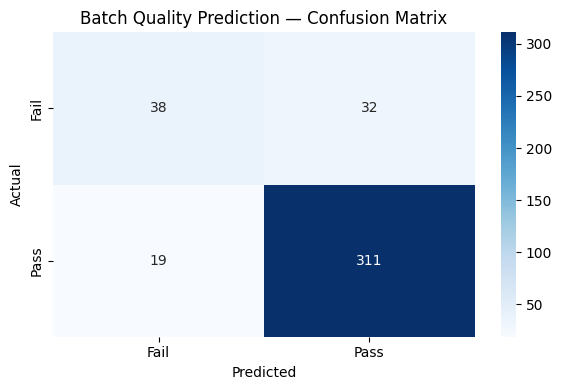

Model trained successfully.


In [3]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --- Generate data ---
np.random.seed(42)
n = 2000
os.makedirs('data', exist_ok=True)

temperature   = np.random.normal(70, 5, n)
pressure      = np.random.normal(2.5, 0.3, n)
ph            = np.random.normal(7.0, 0.4, n)
mixing_speed  = np.random.normal(200, 20, n)
humidity      = np.random.normal(45, 5, n)
reaction_time = np.random.normal(120, 10, n)

fail_prob = (
    (np.abs(temperature - 70) > 8).astype(int) * 0.5 +
    (np.abs(pressure - 2.5) > 0.5).astype(int) * 0.4 +
    (np.abs(ph - 7.0) > 0.6).astype(int) * 0.5 +
    (np.abs(mixing_speed - 200) > 35).astype(int) * 0.3 +
    (humidity > 55).astype(int) * 0.2
)

batch_quality = (fail_prob < np.random.uniform(0, 1, n)).astype(int)

df = pd.DataFrame({
    'temperature': temperature.round(2),
    'pressure': pressure.round(3),
    'ph': ph.round(3),
    'mixing_speed': mixing_speed.round(1),
    'humidity': humidity.round(2),
    'reaction_time': reaction_time.round(1),
    'batch_quality': batch_quality
})

df.to_csv('data/batch_quality_data.csv', index=False)
print(f"Data ready: {len(df)} batches | Pass rate: {df['batch_quality'].mean()*100:.1f}%")

# --- Train model ---
X = df.drop('batch_quality', axis=1)
y = df['batch_quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\n=== BATCH QUALITY MODEL RESULTS ===")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fail','Pass'],
            yticklabels=['Fail','Pass'])
plt.title('Batch Quality Prediction — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()
print("Model trained successfully.")

/tmp/ipykernel_4221/1929764768.py:9: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:,:,1], X_test, plot_type="bar",


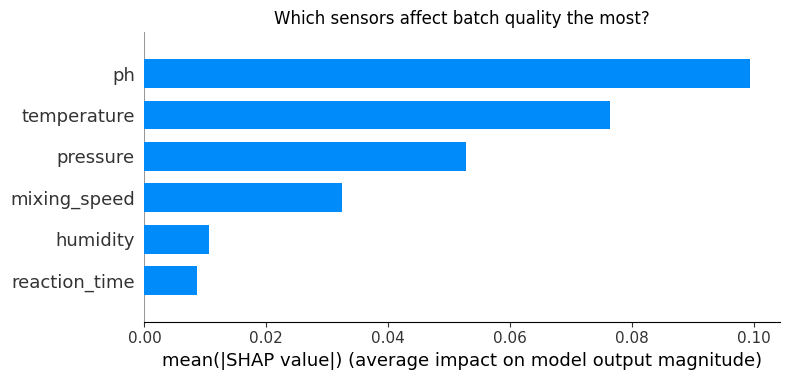

/tmp/ipykernel_4221/1929764768.py:15: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:,:,1], X_test, show=False)


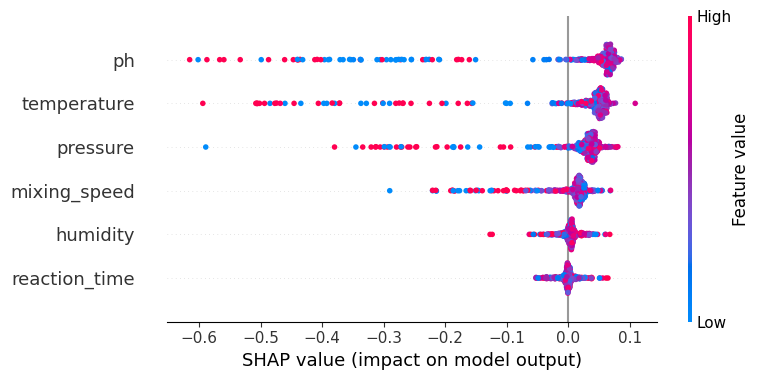

SHAP explainability done.


In [4]:
!pip install shap -q

import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values[:,:,1], X_test, plot_type="bar",
                  show=False)
plt.title("Which sensors affect batch quality the most?")
plt.tight_layout()
plt.show()

shap.summary_plot(shap_values[:,:,1], X_test, show=False)
plt.tight_layout()
plt.show()

print("SHAP explainability done.")

My model identified that pH deviation is the leading cause of batch failures that's accounting for the highest impact on quality outcomes. This aligns with GMP manufacturing where pH control is critical in biologics and API synthesis